In [14]:
!mamba install pandas
!mamba install seaborn


mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.673 seconds
All requested packages already installed.
mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.215 seconds
  Name          Version  Build                Channel
-------------------------------------------------------------------
+ patsy         1.0.2    py313h1804a44_3      emscripten-forge-4x
+ seaborn       0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base  0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels   0.14.6   np23py313hd8db738_2  emscripten-forge-4x


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Dataset .csv')
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [12]:
# Task 1
# Step 1
print("Inspection")
print(f"Cuisine Column Data Type: {df['Cuisines'].dtype}")
print(f"Missing Values: {df['Cuisines'].isnull().sum()}\n")

# Step 2: Clean, Normalize, and Explode Individual Cuisines
df['Cuisines'] = df['Cuisines'].fillna('Unknown')
df_exploded = df.assign(Cuisines=df['Cuisines'].str.split(', ')).explode('Cuisines')

# Step 3: Frequency Distribution & Top 3 Extraction
cuisine_counts = df_exploded['Cuisines'].value_counts()
top_3_cuisines = cuisine_counts.head(3)

print(" Top 3 Cuisines (Absolute Counts) ")
print(top_3_cuisines)
print("\n")

# Step 4: Statistical Representation (Percentage)
total_records = len(df_exploded)
top_3_percentages = (top_3_cuisines / total_records) * 100

print("Top 3 Cuisines (Percentage)")
for cuisine, pct in top_3_percentages.items():
    print(f"{cuisine}: {pct:.2f}%")

Inspection
Cuisine Column Data Type: str
Missing Values: 0

 Top 3 Cuisines (Absolute Counts) 
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


Top 3 Cuisines (Percentage)
North Indian: 20.08%
Chinese: 13.87%
Fast Food: 10.07%


In [11]:
# Task 2
# Step 1: Geographic Density Identification
city_counts = df['City'].value_counts()
highest_density_city = city_counts.index[0]
highest_density_count = city_counts.iloc[0]

print("Highest Restaurant Density")
print(f"City with most restaurants: {highest_density_city} ({highest_density_count} restaurants)\n")

# Step 2 & 3: Data Grouping and Mean Rating Computation
city_grouped_ratings = df.groupby('City')['Aggregate rating'].mean()

# Step 4: Extremum Identification
# Sorting to see the top performing cities
sorted_city_ratings = city_grouped_ratings.sort_values(ascending=False)
highest_rated_city = sorted_city_ratings.index[0]
highest_rated_score = sorted_city_ratings.iloc[0]

print("Top 5 Highest Average Rated Cities")
print(sorted_city_ratings.head(5))
print(f"\nCity with the absolute highest average rating: {highest_rated_city} ({highest_rated_score:.2f})")

Highest Restaurant Density
City with most restaurants: New Delhi (5473 restaurants)

Top 5 Highest Average Rated Cities
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64

City with the absolute highest average rating: Inner City (4.90)


Price Range Tiers
Unique price range categories: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Absolute Frequency per Tier
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


Proportional Market Share (%)
Tier 1: 46.53%
Tier 2: 32.59%
Tier 3: 14.74%
Tier 4: 6.14%




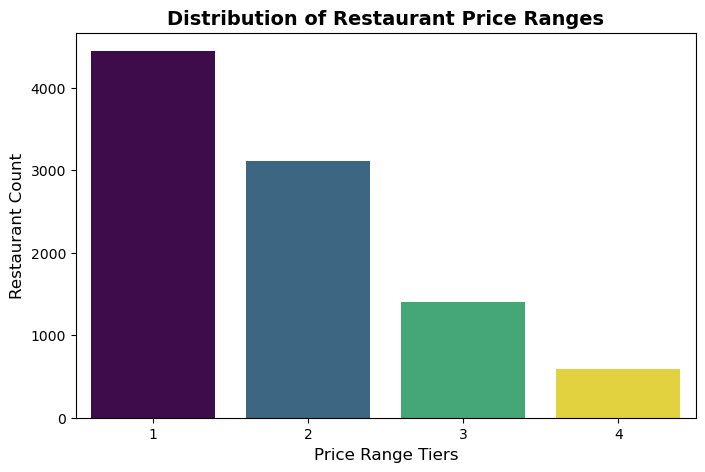

In [18]:
# Task 3
# Step 1: Metric Identification
unique_tiers = df['Price range'].unique()
print("Price Range Tiers")
print(f"Unique price range categories: {sorted(unique_tiers)}\n")

# Step 2: Categorical Group Counting
price_counts = df['Price range'].value_counts().sort_index()
print("Absolute Frequency per Tier")
print(price_counts)
print("\n")

# Step 3: Proportional Distribution Calculation
print("Proportional Market Share (%)")
total_restaurants = len(df)
for tier, count in price_counts.items():
    percentage = (count / total_restaurants) * 100
    print(f"Tier {tier}: {percentage:.2f}%")
print("\n")

# Step 4: Visualizing the Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Price range', hue='Price range', palette='viridis',legend = False)

# Labeling the chart
plt.xlabel('Price Range Tiers', fontsize=12)
plt.ylabel('Restaurant Count', fontsize=12)
plt.title('Distribution of Restaurant Price Ranges', fontsize=14, fontweight='bold')

# Saving and rendering
plt.savefig('price_range_distribution.png', bbox_inches='tight')
plt.show()

In [20]:
# Task 4
# Step 1: Flag Verification
delivery_flags = df['Has Online delivery'].unique()
print("Online Delivery Representation")
print(f"Unique flags found in column: {delivery_flags}\n")

# Step 2: Delivery Market Share Calculation
total_restaurants = len(df)
delivery_yes_count = (df['Has Online delivery'] == 'Yes').sum()
delivery_percentage = (delivery_yes_count / total_restaurants) * 100

print("Delivery Market Share (%)")
print(f"Restaurants with Online Delivery: {delivery_yes_count} ({delivery_percentage:.2f}%)")
print(f"Restaurants without Online Delivery: {total_restaurants - delivery_yes_count} ({100 - delivery_percentage:.2f}%)\n")

# Step 3: Comparative Group Segmentation
delivery_yes = df[df['Has Online delivery'] == 'Yes']
delivery_no = df[df['Has Online delivery'] == 'No']

# Step 4: Statistical Mean Comparison
mean_rating_yes = delivery_yes['Aggregate rating'].mean()
mean_rating_no = delivery_no['Aggregate rating'].mean()

print("Statistical Mean Comparison")
print(f"Average Rating for 'Online Delivery Available': {mean_rating_yes:.2f}")
print(f"Average Rating for 'No Online Delivery': {mean_rating_no:.2f}")
print("-" * 46)

# Definitive Conclusion
if mean_rating_yes > mean_rating_no:
    print(f"Conclusion: Yes, restaurants offering online delivery have a higher average rating by {mean_rating_yes - mean_rating_no:.2f} points.")
else:
    print(f"Conclusion: No, online delivery does not correlate with a higher average rating.")

Online Delivery Representation
Unique flags found in column: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Delivery Market Share (%)
Restaurants with Online Delivery: 2451 (25.66%)
Restaurants without Online Delivery: 7100 (74.34%)

Statistical Mean Comparison
Average Rating for 'Online Delivery Available': 3.25
Average Rating for 'No Online Delivery': 2.47
----------------------------------------------
Conclusion: Yes, restaurants offering online delivery have a higher average rating by 0.78 points.
